# Healthcare Patient Analytics Project: Understanding Readmissions

## Project Overview

**Goal**: Analyze patient readmissions to identify key risk factors and understand resource utilization. This project aims to build a foundation for a dashboard (to be visualized in Power BI later) that can assist clinicians and administrators in improving patient outcomes and optimizing hospital resources.

**Key Areas to Cover**:
*   **Data Governance Considerations**: Ethical handling of sensitive patient data.
*   **Privacy-Preserving Steps**: Techniques to ensure patient anonymity.
*   **Readmission Risk Analysis**: Identifying factors contributing to readmissions.
*   **Operational Recommendations**: Actionable insights for hospital management.

**Tools & Technologies**:
*   **Data Processing**: SQL (conceptually for database interaction)
*   **Analysis**: Python (Pandas, NumPy)
*   **Visualization**: Power BI (for final dashboard - *not directly in Colab*)
*   **Validation**: Excel (conceptually for data checks - *not directly in Colab*)
*   **Environment**: Jupyter Notebook (Google Colab)

## 1. Data Generation and Initial Setup

Since we don't have direct access to real-world healthcare datasets, I will generate a synthetic dataset that simulates patient admissions, diagnoses, procedures, and readmission status. This allows us to demonstrate the analytical process without privacy concerns.

In [5]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Set a seed for reproducibility
np.random.seed(42)

# Number of patients
num_patients = 1000

# Generate Patient Demographics
patient_ids = [f'P{i:04d}' for i in range(num_patients)]
ages = np.random.randint(18, 90, num_patients)
genders = np.random.choice(['Male', 'Female', 'Other'], num_patients, p=[0.49, 0.49, 0.02])
ethnicities = np.random.choice(['White', 'Black', 'Asian', 'Hispanic', 'Other'], num_patients, p=[0.5, 0.2, 0.15, 0.1, 0.05])
insurance_types = np.random.choice(['Private', 'Medicare', 'Medicaid', 'Uninsured'], num_patients, p=[0.4, 0.3, 0.2, 0.1])

patients_df = pd.DataFrame({
    'patient_id': patient_ids,
    'age': ages,
    'gender': genders,
    'ethnicity': ethnicities,
    'insurance_type': insurance_types
})

# Generate Admissions Data
admission_ids = [f'A{i:05d}' for i in range(num_patients * 12)] # More admissions than patients
admission_patient_ids = np.random.choice(patient_ids, num_patients * 12, replace=True)

# Generate admission and discharge dates
start_date = datetime(2022, 1, 1)
admission_dates = [start_date + timedelta(days=np.random.randint(0, 365 * 2)) for _ in range(num_patients * 12)]
# Ensure discharge is after admission, with varying lengths of stay
discharge_dates = [ad_date + timedelta(days=np.random.randint(1, 30)) for ad_date in admission_dates]

medical_conditions = [
    'Heart Failure', 'Pneumonia', 'COPD Exacerbation', 'Diabetes Complications',
    'Asthma Exacerbation', 'Sepsis', 'Kidney Disease', 'Stroke', 'Appendicitis', 'Fracture'
]
diagnoses = np.random.choice(medical_conditions, num_patients * 12)

procedures = [
    'Angioplasty', 'Ventilation', 'Dialysis', 'Appendectomy', 'Hip Replacement',
    'Bronchoscopy', 'Chemotherapy', 'Blood Transfusion', 'Wound Debridement', 'No Procedure'
]
performed_procedures = np.random.choice(procedures, num_patients * 12, p=[0.1, 0.1, 0.1, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.4])

# Length of Stay (calculated later from dates)
# Charges
charges = np.random.uniform(5000, 100000, num_patients * 12).round(2)

# Readmission Status (within 30 days of discharge) - simulated based on some risk factors
# Let's make readmission more likely for certain conditions or older patients
readmission_status = []
for i in range(num_patients * 12):
    readmitted = False
    if 'Heart Failure' in diagnoses[i] or 'Kidney Disease' in diagnoses[i]:
        if np.random.rand() < 0.35: # Higher readmission rate for these conditions
            readmitted = True
    elif ages[patients_df[patients_df['patient_id'] == admission_patient_ids[i]].index[0]] > 70:
        if np.random.rand() < 0.25: # Higher readmission rate for older patients
            readmitted = True
    else:
        if np.random.rand() < 0.1: # Baseline readmission rate
            readmitted = True
    readmission_status.append(readmitted)

admissions_df = pd.DataFrame({
    'admission_id': admission_ids,
    'patient_id': admission_patient_ids,
    'admission_date': admission_dates,
    'discharge_date': discharge_dates,
    'primary_diagnosis': diagnoses,
    'procedure_performed': performed_procedures,
    'total_charges': charges,
    'readmitted_30_days': readmission_status
})

# Merge patient demographics with admissions
df = pd.merge(admissions_df, patients_df, on='patient_id', how='left')

# Calculate Length of Stay
df['length_of_stay_days'] = (df['discharge_date'] - df['admission_date']).dt.days

print("Synthetic Dataset Generated:")
display(df.head())
display(df.info())


Synthetic Dataset Generated:


,admission_id,patient_id,admission_date,discharge_date,primary_diagnosis,procedure_performed,total_charges,readmitted_30_days,age,gender,ethnicity,insurance_type,length_of_stay_days
0,A00000,P0863,2022-06-08,2022-07-07,COPD Exacerbation,No Procedure,49602.80,False,50,Male,Asian,Private,29
1,A00001,P0236,2023-05-09,2023-05-17,Asthma Exacerbation,No Procedure,83895.61,False,50,Female,White,Private,8
2,A00002,P0193,2022-11-25,2022-12-14,COPD Exacerbation,No Procedure,30545.04,False,88,Female,Asian,Medicare,19
3,A00003,P0286,2023-09-06,2023-09-27,Heart Failure,Angioplasty,37650.10,False,84,Male,Asian,Medicare,21
4,A00004,P0770,2022-03-24,2022-04-09,Pneumonia,No Procedure,41527.02,False,36,Female,White,Medicaid,16


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   admission_id         12000 non-null  object        
 1   patient_id           12000 non-null  object        
 2   admission_date       12000 non-null  datetime64[ns]
 3   discharge_date       12000 non-null  datetime64[ns]
 4   primary_diagnosis    12000 non-null  object        
 5   procedure_performed  12000 non-null  object        
 6   total_charges        12000 non-null  float64       
 7   readmitted_30_days   12000 non-null  bool          
 8   age                  12000 non-null  int64         
 9   gender               12000 non-null  object        
 10  ethnicity            12000 non-null  object        
 11  insurance_type       12000 non-null  object        
 12  length_of_stay_days  12000 non-null  int64         
dtypes: bool(1), datetime64[ns](2), 

None

## 2. Data Cleaning and Preprocessing

This step involves handling missing values, correcting data types, and creating new features that might be useful for analysis. For our synthetic dataset, the data is relatively clean, but we will perform standard checks and conversions.

In [2]:
# Check for missing values
print("Missing values before cleaning:")
display(df.isnull().sum())

# Data type conversion (already handled during generation for dates, but good to explicitly check/set)
df['admission_date'] = pd.to_datetime(df['admission_date'])
df['discharge_date'] = pd.to_datetime(df['discharge_date'])

# Ensure categorical features are of 'category' dtype for efficiency and proper handling
for col in ['gender', 'ethnicity', 'insurance_type', 'primary_diagnosis', 'procedure_performed']:
    if col in df.columns:
        df[col] = df[col].astype('category')

# Verify data types
print("\nData types after cleaning:")
display(df.info())


Missing values before cleaning:


,0
admission_id,0
patient_id,0
admission_date,0
discharge_date,0
primary_diagnosis,0
procedure_performed,0
total_charges,0
readmitted_30_days,0
age,0
gender,0



Data types after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   admission_id         12000 non-null  object        
 1   patient_id           12000 non-null  object        
 2   admission_date       12000 non-null  datetime64[ns]
 3   discharge_date       12000 non-null  datetime64[ns]
 4   primary_diagnosis    12000 non-null  category      
 5   procedure_performed  12000 non-null  category      
 6   total_charges        12000 non-null  float64       
 7   readmitted_30_days   12000 non-null  bool          
 8   age                  12000 non-null  int64         
 9   gender               12000 non-null  category      
 10  ethnicity            12000 non-null  category      
 11  insurance_type       12000 non-null  category      
 12  length_of_stay_days  12000 non-null  int64         
dtypes: 

None

## 3. Exploratory Data Analysis (EDA)

EDA helps us understand the distribution of our data, identify patterns, and uncover initial insights. We'll look at demographics, common diagnoses, and initial readmission rates.

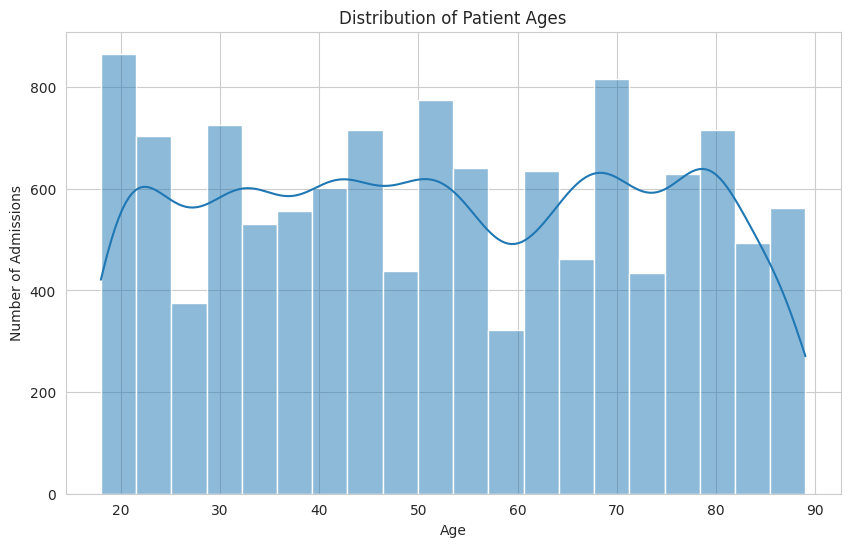

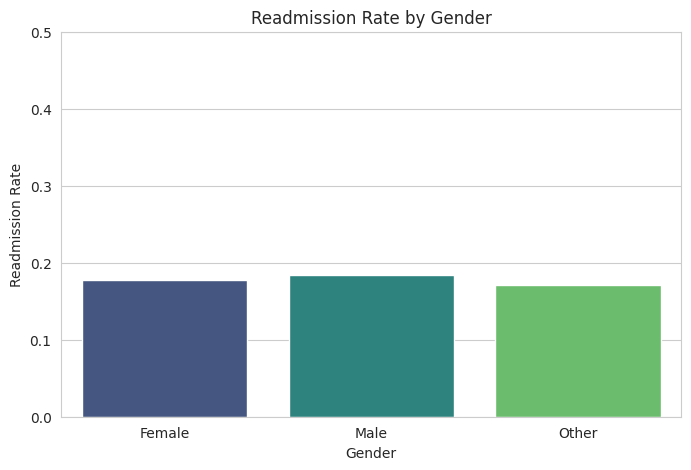

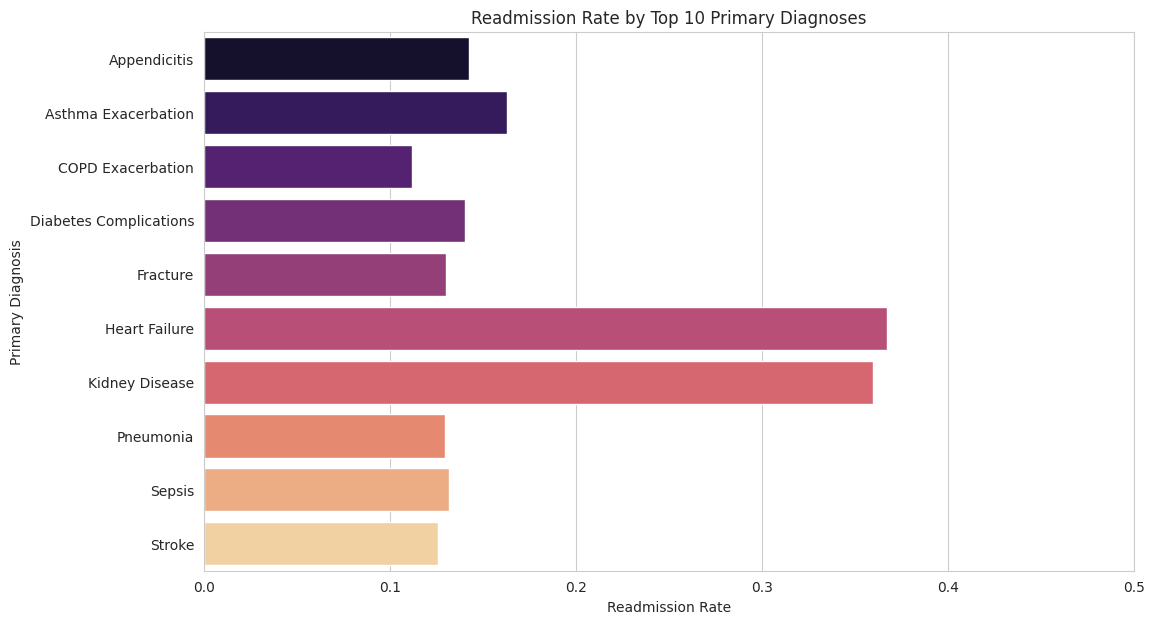


Overall 30-day Readmission Rate: 18.00%


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Distribution of Age
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Distribution of Patient Ages')
plt.xlabel('Age')
plt.ylabel('Number of Admissions')
plt.show()

# Readmission Rate by Gender
readmission_by_gender = df.groupby('gender', observed=False)['readmitted_30_days'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(x='gender', y='readmitted_30_days', data=readmission_by_gender, palette='viridis', hue='gender', legend=False)
plt.title('Readmission Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Readmission Rate')
plt.ylim(0, 0.5) # Set consistent y-axis for rates
plt.show()

# Top 10 Primary Diagnoses and their Readmission Rates
diagnosis_counts = df['primary_diagnosis'].value_counts().head(10).index
top_diagnoses_df = df[df['primary_diagnosis'].isin(diagnosis_counts)]

readmission_by_diagnosis = top_diagnoses_df.groupby('primary_diagnosis', observed=False)['readmitted_30_days'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='readmitted_30_days', y='primary_diagnosis', data=readmission_by_diagnosis, palette='magma', hue='primary_diagnosis', legend=False)
plt.title('Readmission Rate by Top 10 Primary Diagnoses')
plt.xlabel('Readmission Rate')
plt.ylabel('Primary Diagnosis')
plt.xlim(0, 0.5) # Set consistent x-axis for rates
plt.show()

# Overall Readmission Rate
overall_readmission_rate = df['readmitted_30_days'].mean()
print(f"\nOverall 30-day Readmission Rate: {overall_readmission_rate:.2%}")